<a href="https://colab.research.google.com/github/vedikapathak43-ai/Data_Science_70/blob/main/practical_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📊 DATASET PREVIEW
 userId  movieId  rating  timestamp                       title                                      genres
      1        1     4.0  964982703            Toy Story (1995) Adventure|Animation|Children|Comedy|Fantasy
      1        3     4.0  964981247     Grumpier Old Men (1995)                              Comedy|Romance
      1        6     4.0  964982224                 Heat (1995)                       Action|Crime|Thriller
      1       47     5.0  964983815 Seven (a.k.a. Se7en) (1995)                            Mystery|Thriller
      1       50     5.0  964982931  Usual Suspects, The (1995)                      Crime|Mystery|Thriller


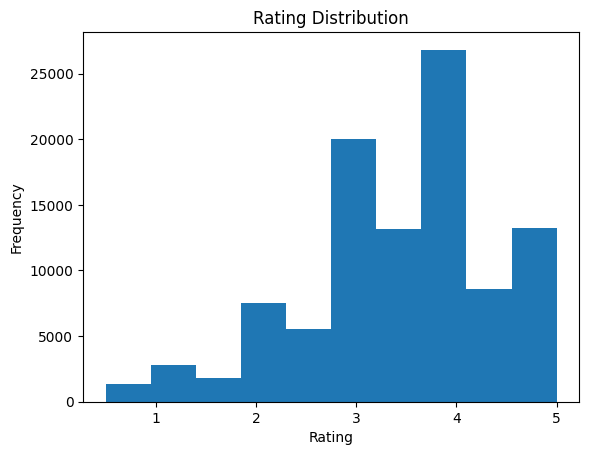


📈 REGRESSION RESULT
RMSE: 0.965

📊 CLASSIFICATION RESULT
Accuracy: 0.657

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.65     20168


Confusion Matrix:
[[4005 3824]
 [3102 9237]]

🔍 USER INPUT PREDICTION
Enter User ID: 1
Enter Movie ID: 6
Enter Genre Code (numeric): 3

🎯 PREDICTION RESULT
 User ID  Movie ID  Genre Code  Predicted Rating Rating Category
       1         6           3              3.28            High

✅ Practical Completed Successfully!


In [2]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix

# =========================================
# 2. Extract Dataset
# =========================================
with zipfile.ZipFile("ml-latest-small.zip", 'r') as zip_ref:
    zip_ref.extractall()

# =========================================
# 3. Load Data
# =========================================
ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies = pd.read_csv("ml-latest-small/movies.csv")

data = pd.merge(ratings, movies, on="movieId")

print("\n📊 DATASET PREVIEW")
print(data.head().to_string(index=False))

# =========================================
# 4. Visualization
# =========================================
plt.hist(data['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# =========================================
# 5. Preprocessing
# =========================================
data['genres'] = data['genres'].astype('category').cat.codes

X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

# =========================================
# 6. Train Regression Model
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

reg = RandomForestRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📈 REGRESSION RESULT")
print(f"RMSE: {rmse:.3f}")

# =========================================
# 7. Classification Conversion
# =========================================
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)
y_cls = data['rating_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

# =========================================
# 8. Classification Results
# =========================================
print("\n📊 CLASSIFICATION RESULT")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cls):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cls))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cls))

# =========================================
# 9. USER INPUT PREDICTION
# =========================================
print("\n🔍 USER INPUT PREDICTION")

try:
    user_id = int(input("Enter User ID: "))
    movie_id = int(input("Enter Movie ID: "))
    genre_code = int(input("Enter Genre Code (numeric): "))

    input_data = pd.DataFrame([[user_id, movie_id, genre_code]],
                              columns=['userId', 'movieId', 'genres'])

    pred_rating = reg.predict(input_data)[0]
    pred_class = clf.predict(input_data)[0]

    # Clean Output Table
    result_df = pd.DataFrame({
        "User ID": [user_id],
        "Movie ID": [movie_id],
        "Genre Code": [genre_code],
        "Predicted Rating": [round(pred_rating, 2)],
        "Rating Category": ["High" if pred_class == 1 else "Low"]
    })

    print("\n🎯 PREDICTION RESULT")
    print(result_df.to_string(index=False))

except:
    print("Invalid Input! Please enter numeric values.")

print("\n✅ Practical Completed Successfully!")